Setting the S/N of the test set to 50, and changing the S/N of training sets to see how it performs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *

In [2]:
file = "sfh_50_20260224_110556"

p1000 = 10**(np.load(f"/avatar/vmehta/{file}/noiseless-training/snr1000_pred.npy"))
p500 = 10**(np.load(f"/avatar/vmehta/{file}/noiseless-training/snr500_pred.npy"))
p200 = 10**(np.load(f"/avatar/vmehta/{file}/noiseless-training/snr200_pred.npy"))
p100 = 10**(np.load(f"/avatar/vmehta/{file}/noiseless-training/snr100_pred.npy"))
p50 = 10**(np.load(f"/avatar/vmehta/{file}/noiseless-training/snr50_pred.npy"))
true = 10**(np.load(f"/avatar/vmehta/{file}/noiseless-training/snr500_true.npy"))

In [3]:
bin_arr = np.r_[np.array([0.1, 20, 50, 100, 200, 500])*1e6, np.logspace(9.5, 10.15, 5)]
binning = np.log10(bin_arr)
bin_widths = np.diff(binning)
bin_centers = binning[:-1] + bin_widths/2

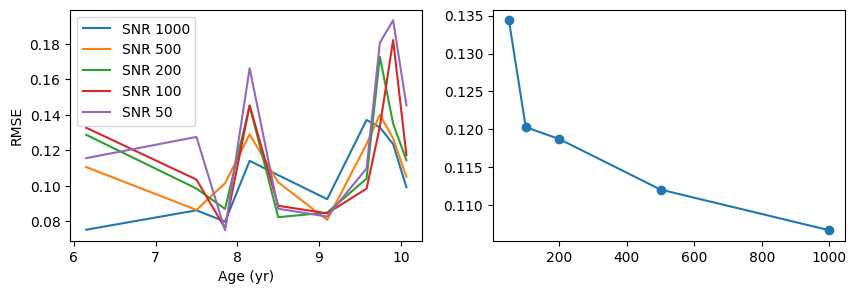

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10,3), sharey=False)

ax[0].plot(bin_centers, rmse(true, p1000)[0], label='SNR 1000')
ax[0].plot(bin_centers, rmse(true, p500)[0], label='SNR 500')
ax[0].plot(bin_centers, rmse(true, p200)[0], label='SNR 200')
ax[0].plot(bin_centers, rmse(true, p100)[0], label='SNR 100')
ax[0].plot(bin_centers, rmse(true, p50)[0], label='SNR 50')
ax[0].set_xlabel('Age (yr)')
ax[0].set_ylabel('RMSE')
ax[0].legend()

ax[1].plot([50, 100, 200, 500, 1000], [rmse(true, p50)[1], rmse(true, p100)[1], rmse(true, p200)[1], rmse(true, p500)[1], rmse(true, p1000)[1]], marker='o')

setting train and test data to snr=2000 but changing inverse variance arrays based on what they would be from different snr. note that we are changing inverse variances in the training step only, inverse variances of test set are at snr=2000

In [5]:
file = "sfh_100_20260224_112931"
fexact = 10**(np.load(f"/avatar/vmehta/{file}/noiseless-training/snr2000_pred.npy"))
f1000 = 10**(np.load(f"/avatar/vmehta/{file}/noiseless-training/snr1000_pred.npy"))
f500 = 10**(np.load(f"/avatar/vmehta/{file}/noiseless-training/snr500_pred.npy"))
f50 = 10**(np.load(f"/avatar/vmehta/{file}/noiseless-training/snr50_pred.npy"))
ftrue = 10**(np.load(f"/avatar/vmehta/{file}/noiseless-training/snr2000_true.npy"))

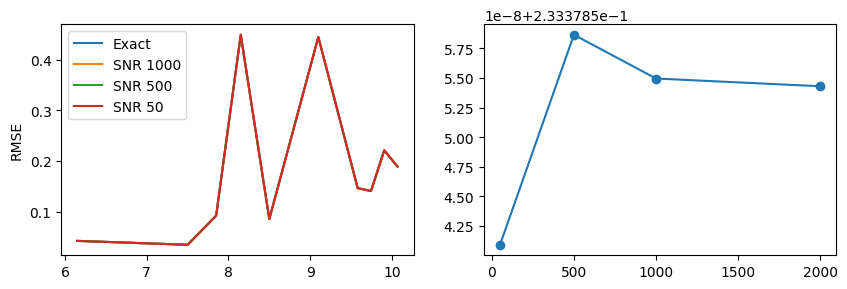

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10,3), sharey=False)

ax[0].plot(bin_centers, rmse(ftrue, fexact)[0], label='Exact')
ax[0].plot(bin_centers, rmse(ftrue, f1000)[0], label='SNR 1000')
ax[0].plot(bin_centers, rmse(ftrue, f500)[0], label='SNR 500')
# ax[0].plot(bin_centers, rmse(ftrue, f200)[0], label='SNR 200')
# ax[0].plot(bin_centers, rmse(ftrue, f100)[0], label='SNR 100')
ax[0].plot(bin_centers, rmse(ftrue, f50)[0], label='SNR 50')
# ax[0].set_xlabel('Age (yr)')
ax[0].set_ylabel('RMSE')
ax[0].legend()

ax[1].plot([50, 500, 1000, 2000], [rmse(ftrue, f50)[1], rmse(ftrue, f500)[1], rmse(ftrue, f1000)[1], rmse(ftrue, fexact)[1]], marker='o')

In [7]:
rmse(ftrue, fexact)[0]

array([0.04218669, 0.03451034, 0.09205514, 0.44948499, 0.08531379,
       0.44506193, 0.14642268, 0.14073196, 0.22110365, 0.18890061])

In [8]:
rmse(ftrue, f50)[1]

np.float64(0.23337854091494445)

doing the same as above but changing inverse variance arrays for both training and test step (setting them both to the same).

In [9]:
file = "sfh_100_20260224_115128"
f1000 = 10**(np.load(f"/avatar/vmehta/{file}/noiseless-training/snr1000_pred.npy"))
f500 = 10**(np.load(f"/avatar/vmehta/{file}/noiseless-training/snr500_pred.npy"))
#f100 = 10**(np.load(f"/avatar/vmehta/{file}/noiseless-training/snr100_pred.npy"))
f50 = 10**(np.load(f"/avatar/vmehta/{file}/noiseless-training/snr50_pred.npy"))
ftrue = 10**(np.load(f"/avatar/vmehta/{file}/noiseless-training/snr1000_true.npy"))

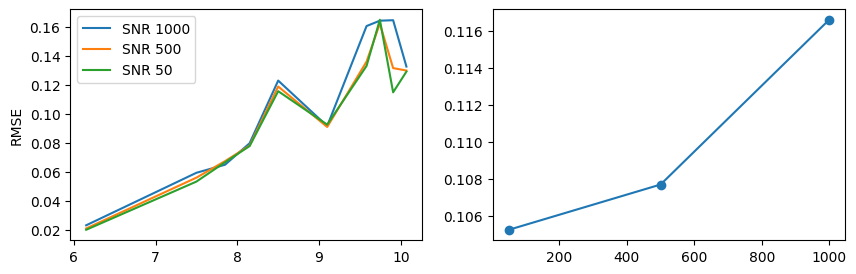

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(10,3), sharey=False)

#ax[0].plot(bin_centers, rmse(ftrue, fexact)[0], label='Exact')
ax[0].plot(bin_centers, rmse(ftrue, f1000)[0], label='SNR 1000')
ax[0].plot(bin_centers, rmse(ftrue, f500)[0], label='SNR 500')
# ax[0].plot(bin_centers, rmse(ftrue, f200)[0], label='SNR 200')
# ax[0].plot(bin_centers, rmse(ftrue, f100)[0], label='SNR 100')
ax[0].plot(bin_centers, rmse(ftrue, f50)[0], label='SNR 50')
# ax[0].set_xlabel('Age (yr)')
ax[0].set_ylabel('RMSE')
ax[0].legend()

ax[1].plot([50, 500, 1000], [rmse(ftrue, f50)[1], rmse(ftrue, f500)[1], rmse(ftrue, f1000)[1]], marker='o')

/tmp/ipykernel_4079651/1659352756.py:3: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  m = pickle.load(open(f"/avatar/vmehta/{file}/noisy-training/snr100_model.pkl", 'rb'))


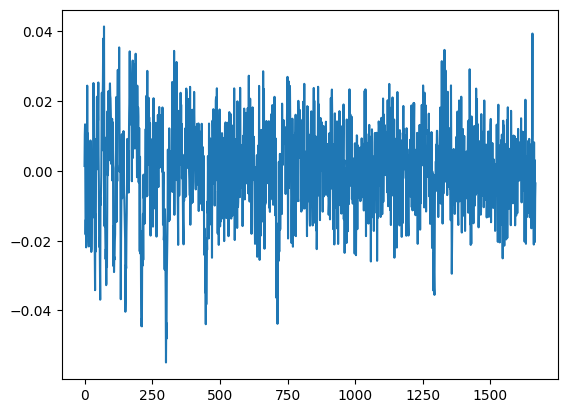

In [11]:
file = "sfh_100_20260224_103549"
import pickle
m = pickle.load(open(f"/avatar/vmehta/{file}/noisy-training/snr100_model.pkl", 'rb'))
plt.plot(m['theta'][:,2])

/tmp/ipykernel_4079651/3604213664.py:2: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  f = pickle.load(open(f"/avatar/vmehta/{file}/noiseless-training/snr_model.pkl", 'rb'))


(array([   0.,    0.,    0.,    0.,    0., 1667.,    0.,    0.,    0.,
           0.]),
 array([-0.5, -0.4, -0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3,  0.4,  0.5]),
 <BarContainer object of 10 artists>)

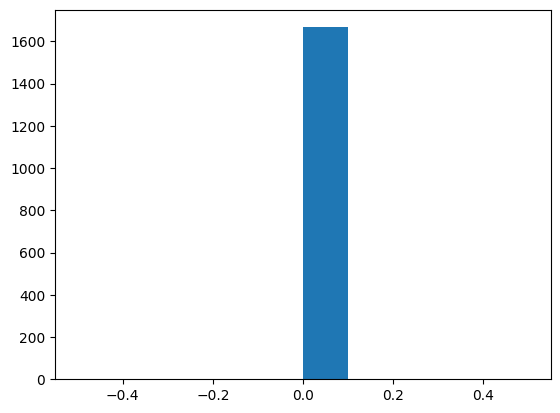

In [13]:
file = "sfh_100_20260224_115128"
f = pickle.load(open(f"/avatar/vmehta/{file}/noiseless-training/snr_model.pkl", 'rb'))
plt.hist(f['s2'])